# Overlap and divergence of anomaly scores

In [2]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from anomaly.utils import VelocityFilter
from anomaly.utils import AnomalyOverlapAnalyzer
from autoencoders.ae import AutoEncoder

from sdss.metadata import MetaData

meta = MetaData()

# Constants

In [4]:
se_cols = [
    'mse',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_97',
    # 'mse_95',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]

se_rank_cols = [
    f"rank_{col}" for col in se_cols
]

# ----------------------------------------------
rse_cols = [
    f"{col}_rel" for col in se_cols
]

rse_rank_cols = [
    f"rank_{col}_rel" for col in se_cols
]
# ----------------------------------------------
se_family = [
    'mse',
    'mse_97',
    # 'mse_95',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]

rse_family = [
    f'{col}_rel' for col in se_family
]

# Custom functions

## Score name map

In [5]:
def map_score_name(score):
    """Maps score code names to more readable names."""
    if score == 'mse':
        return 'SE'
    elif score == 'mse_filter_250':
        return 'Filtered SE'
    elif score == 'mse_97':
        return 'Trimmed SE'
    elif score == 'mse_filter_250_97':
        return 'Filtered + Trimmed SE'
    
    elif score == 'mse_rel':
        return 'RSE'
    elif score == 'mse_filter_250_rel':
        return 'Filtered RSE'
    elif score == 'mse_97_rel':
        return 'Trimmed RSE'
    elif score == 'mse_filter_250_97_rel':
        return 'Filtered + Trimmed RSE'
    else:
        return score

## IDs top anomalies

In [6]:
def get_ids_set(score, df, quantile=99, n_top=None, use_ntop=False):

    if use_ntop is False:
        
        quantile *= 0.01
        thresh = df[score].quantile(quantile)
        ids = set(df[df[score] > thresh].index)
        
    else:

        ids = set(
            df[score].sort_values(
                ascending=False
            ).iloc[:n_top].index
        )

    return ids

In [7]:
def top_unique_ids(scores_df, scores_list, quantile=99, n_top=None, use_ntop=False):

    ids_top_dict = {}

    ids_top_list = []

    for score in scores_list:

        ids_set = get_ids_set(
            score=score,
            df=scores_df,
            quantile=quantile,
            n_top=n_top,
            use_ntop=use_ntop
        )

        ids_top_dict[score] = ids_set

        ids_top_list += list(ids_set)


    n_dictinct_top = len(set(ids_top_list))

    print(f"N unique: {n_dictinct_top}")


    unique_ids_dict = AnomalyOverlapAnalyzer.get_unique_ids(
        ids_dict=ids_top_dict, score_list=scores_list
    )

    for score in scores_list:
        n_unique = len(unique_ids_dict[score])

        unique_pct = n_unique/n_dictinct_top*100
        
        print(f"Unique to {score}:\n{n_unique} --> {unique_pct:.4f}%")

    return unique_ids_dict, ids_top_dict, n_dictinct_top


In [8]:
def top_common_ids(scores_df, scores_list, quantile=99, n_top=None, use_ntop=False):

    ids_top_dict = {}
    ids_top_list = []


    for score in scores_list:

        ids_set = get_ids_set(
            score=score,
            df=scores_df,
            quantile=quantile,
            n_top=n_top,
            use_ntop=use_ntop
        )

        ids_top_dict[score] = ids_set

        ids_top_list += list(ids_set)

    n_dictinct_top = len(set(ids_top_list))
    print(f"N unique: {n_dictinct_top}")

    common_ids_set = AnomalyOverlapAnalyzer.get_core_common_ids(
        ids_dict=ids_top_dict, score_list=scores_list
    )

    n_common = len(common_ids_set)
    common_pct = n_common/n_dictinct_top*100 
    print(f"N common:\n{n_common} -- > {common_pct:4f}%")

    return common_ids_set, ids_top_dict, n_dictinct_top, n_common 

## Figures

In [9]:
def anomaly_plot(wave, specs, objids, ranks, save_to):

    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    for spec, objid, rank in zip(specs, objids, ranks):

        print(f'Rank {rank:03d}', end='\r')

        ax.clear()

        ax.plot(wave, spec, color="black", label=f'Rank: {rank}')

        ax.minorticks_on()
        ax.set_xlabel(r"$\lambda$ [nm]")
        ax.set_title(f"Object ID: {objid}")

        ax.legend(
            loc='upper left',
            frameon=False,
        )

        fig.savefig(
            f"{save_to}/{rank:03d}_{objid}.jpeg",
            bbox_inches='tight'
        )

    plt.close(fig)

# Config

## Directories

In [10]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
bin_id = 'bin_03'
#
ch_4_dir = f"{thesis_dir}/chapters/04_figures"
os.makedirs(f"{ch_4_dir}/{bin_id}", exist_ok=True)

## Data

In [11]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)

## scores

In [12]:
score_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

rank = np.arange(score_df.shape[0]) + 1
score_rank_df = score_df.copy()
# score_rank_df
for col in score_df.columns:

    index_sorted = score_df.sort_values(
        by=col, ascending=False
    ).index

    score_rank_df.loc[index_sorted, f'rank_{col}'] = rank
    score_rank_df[f'rank_{col}'].astype(int)

n_spec = score_df.shape[0]
n_top_1_pct = int(n_spec*0.01)
n_top_1_pct, n_spec

(1818, 181850)

In [13]:
score = 'mse_97'
score_rank_df[[score, f'rank_{score}']].sort_values(
    by=score, ascending=False
).head(10)

,mse_97,rank_mse_97
specobjid,,
1919783100783552512,14.699505,1.0
2245159102839810048,13.236768,2.0
2930814289679771648,10.930245,3.0
1071977423131666432,10.445363,4.0
969534273977608192,9.671392,5.0
2008626123889469440,9.139043,6.0
1530151624956209152,8.159980,7.0
2811439757043722240,7.990755,8.0
1935588031146780672,7.488008,9.0


# IDs per score
Get specobjid for top 1\% of anomalies of each score

In [14]:
ids_top_dict = {}

all_scores = se_cols + rse_cols

for score in all_scores:

    ids_top_dict[score] = get_ids_set(
        score=score,
        df=score_df.copy(),
        quantile=99,
        n_top=1000,
        use_ntop=False
    )

In [15]:
[
    n for n 
    in [len(v) for v in ids_top_dict.values()]
]

[1819, 1819, 1819, 1819, 1819, 1819, 1819, 1819]

# Distinct IDs

## SE family

In [16]:
se_unique_ids_dict, se_ids_top_dict, n_dictinct_top_se = top_unique_ids(
    scores_df=score_df.copy(),
    scores_list=se_cols,
    quantile=99,
    n_top=None, use_ntop=False
)

N unique: 3173
Unique to mse:
433 --> 13.6464%
Unique to mse_filter_250:
261 --> 8.2257%
Unique to mse_97:
63 --> 1.9855%
Unique to mse_filter_250_97:
143 --> 4.5068%


In [17]:
n_dictinct_top_se/(1819*4)*100

43.60912589334799

In [18]:
n_unique_per_score_all = 433 + 261 + 63 + 143
n_unique_per_score_all/n_dictinct_top_se*100

28.364323983611722

**N unique: 3173** 
There are 3173 unique anomalous objects among all top 1\% in each SE score.

This means that 3173/(4*1819) = 0.43609

That is, a 43.6% are unique anomalies of all added together in SE scores

* Unique to mse: 
433 --> 13.6464%
* Unique to mse_filter_250: 
261 --> 8.2257%
* Unique to mse_97: 
63 --> 1.9855%
* Unique to mse_filter_250_97: 
143 --> 4.5068%

In [19]:
score = 'mse_97'
unique_score_ids = list(se_unique_ids_dict[score])
# 
n = len(unique_score_ids)
print(
    f"N unique to {score}: {n} --> {n/n_dictinct_top_se*100:.2f}%"
    " among all SE anomalies"
)
# 
score_rank_df.loc[
    unique_score_ids, [score, f'rank_{score}']
].sort_values(by=score, ascending=False).head()

N unique to mse_97: 63 --> 1.99% among all SE anomalies


,mse_97,rank_mse_97
specobjid,,
2486065949363431424,3.395724,825.0
1920948851175352320,3.336652,940.0
2044708513611016192,3.318774,990.0
1010024344241334272,3.219751,1274.0
2942098302671284224,3.217373,1279.0


### Figs unique per SE

In [20]:
# plt.ioff()

# for score in se_cols:

#     specids = list(se_unique_ids_dict[score])
#     specids = np.array(specids, dtype=int)

#     ranks = score_rank_df.loc[
#         specids, f'rank_{score}'
#     ].to_numpy().astype(int)

#     specs = np.empty((len(specids), wave.size))

#     for i, objid in enumerate(specids):

#         spec_idx = specobjid_to_idx(
#             objid, idx_id_spec
#         )

#         specs[i, :] = spectra[spec_idx, :]

#     # -----------------------------------------------------------

#     save_to = f"{scores_dir}/{bin_id}/figs/unique_se/{score}"

#     os.makedirs(save_to, exist_ok=True)

#     anomaly_plot(
#         wave_nm, specs=specs,
#         objids=specids, ranks=ranks,
#         save_to=save_to
#     )

## RSE family

In [21]:
rse_unique_ids_dict, rse_ids_top_dict, n_dictinct_top_rse = top_unique_ids(
    scores_df=score_df.copy(),
    scores_list=rse_cols,
    quantile=99,
    # n_top=1000, use_ntop=True
)

N unique: 3107
Unique to mse_rel:
309 --> 9.9453%
Unique to mse_filter_250_rel:
190 --> 6.1152%
Unique to mse_97_rel:
158 --> 5.0853%
Unique to mse_filter_250_97_rel:
177 --> 5.6968%


In [22]:
n_dictinct_top_rse/(1819*4)*100

42.702034084661896

In [23]:
n_unique_per_score_all_rse = 309 + 190 + 158 + 177
n_unique_per_score_all_rse/n_dictinct_top_rse*100

26.842613453492113

In [24]:
score = 'mse_97_rel'
unique_res_ids = list(rse_unique_ids_dict[score])
score_rank_df.loc[
    unique_res_ids, [score, f'rank_{score}']
].sort_values(by=score, ascending=False).head()

,mse_97_rel,rank_mse_97_rel
specobjid,,
1781231151415846912,3.541895,666.0
511298502572140544,3.493030,766.0
2486033238892505088,3.486292,781.0
2553545448539318272,3.468160,815.0
2026696588415494144,3.455466,850.0


### Figs unique per RES

In [25]:
# plt.ioff()

# for score in rse_cols:

#     specids = list(rse_unique_ids_dict[score])
#     specids = np.array(specids, dtype=int)

#     ranks = score_rank_df.loc[
#         specids, f'rank_{score}'
#     ].to_numpy().astype(int)

#     specs = np.empty((len(specids), wave.size))

#     for i, objid in enumerate(specids):

#         spec_idx = specobjid_to_idx(
#             objid, idx_id_spec
#         )

#         specs[i, :] = spectra[spec_idx, :]

#     # -----------------------------------------------------------

#     save_to = f"{scores_dir}/{bin_id}/figs/unique_rse/{score}"

#     os.makedirs(save_to, exist_ok=True)

#     anomaly_plot(
#         wave_nm, specs=specs,
#         objids=specids, ranks=ranks,
#         save_to=save_to
#     )

## All scores

In [26]:
all_scores = se_cols + rse_cols

all_unique_ids_dict, all_ids_top_dict, n_dictinct_top_all = top_unique_ids(
    scores_df=score_df.copy(),
    scores_list=all_scores,
    quantile=99,
    # n_top=1000, use_ntop=True
)

N unique: 4095
Unique to mse:
262 --> 6.3980%
Unique to mse_filter_250:
128 --> 3.1258%
Unique to mse_97:
46 --> 1.1233%
Unique to mse_filter_250_97:
61 --> 1.4896%
Unique to mse_rel:
45 --> 1.0989%
Unique to mse_filter_250_rel:
125 --> 3.0525%
Unique to mse_97_rel:
64 --> 1.5629%
Unique to mse_filter_250_97_rel:
146 --> 3.5653%


In [27]:
n_dictinct_top_all/(1819*8)*100

28.14046179219351

In [28]:
n_unique_per_score_all_all = 262 + 128 + 46 + 61 + 45 + 125 + 64 + 146
n_unique_per_score_all_all/n_dictinct_top_all*100

21.416361416361415

In [29]:
score = 'mse'
unique_all_ids = list(all_unique_ids_dict[score])
score_rank_df.loc[
    unique_all_ids, [score, f'rank_{score}']
].sort_values(by=score, ascending=False).head()

,mse,rank_mse
specobjid,,
2201231682403592192,9.990168,211.0
495462511089313792,9.045976,279.0
2291377342129399808,8.804863,299.0
2359927219364587520,8.752784,306.0
1934299677960726528,8.700253,309.0


### Figs unique among all

In [30]:
# all_scores = se_cols + rse_cols
# plt.ioff()

# for score in all_scores:

#     specids = list(all_unique_ids_dict[score])
#     specids = np.array(specids, dtype=int)

#     ranks = score_rank_df.loc[
#         specids, f'rank_{score}'
#     ].to_numpy().astype(int)

#     specs = np.empty((len(specids), wave.size))

#     for i, objid in enumerate(specids):

#         spec_idx = specobjid_to_idx(
#             objid, idx_id_spec
#         )

#         specs[i, :] = spectra[spec_idx, :]

#     # -----------------------------------------------------------

#     save_to = f"{scores_dir}/{bin_id}/figs/unique_all/{score}"

#     os.makedirs(save_to, exist_ok=True)

#     anomaly_plot(
#         wave_nm, specs=specs,
#         objids=specids, ranks=ranks,
#         save_to=save_to
#     )

# Common IDs

## SE family

In [31]:
se_common_ids, se_ids_top_dict, n_dictinct_se, n_common_se = top_common_ids(
    scores_df=score_df.copy(), scores_list=se_cols,
    quantile=99,
    n_top=None, use_ntop=False
)

N unique: 3173
N common:
692 -- > 21.809014%


In [32]:
n_dictinct_se, n_common_se

(3173, 692)

In [33]:
common_se_ids = list(se_common_ids)
score_rank_df.loc[
    common_se_ids, se_rank_cols
].sort_values(by='rank_mse', ascending=True).head()

,rank_mse,rank_mse_filter_250,rank_mse_97,rank_mse_filter_250_97
specobjid,,,,
1413149843194406912,2.0,2.0,52.0,37.0
1767703038748813312,4.0,4.0,35.0,38.0
2930814289679771648,5.0,33.0,3.0,4.0
1610143844655982592,6.0,5.0,143.0,166.0
305239577747023872,8.0,12.0,237.0,397.0


### Figs common among SE

In [34]:
# specids = list(se_common_ids)
# specids = np.array(specids, dtype=int)

# ranks = score_rank_df.loc[
#     specids, f'rank_mse'
# ].to_numpy().astype(int)

# specs = np.empty((len(specids), wave.size))

# for i, objid in enumerate(specids):

#     spec_idx = specobjid_to_idx(
#         objid, idx_id_spec
#     )

#     specs[i, :] = spectra[spec_idx, :]

# # -----------------------------------------------------------

# save_to = f"{scores_dir}/{bin_id}/figs/common_ses/"

# os.makedirs(save_to, exist_ok=True)

# anomaly_plot(
#     wave_nm, specs=specs,
#     objids=specids, ranks=ranks,
#     save_to=save_to
# )

## RSE Family

In [35]:
rse_common_ids, res_ids_top_dict, n_dictinct_rse, n_common_rse = top_common_ids(
    scores_df=score_df.copy(), scores_list=rse_cols,
    quantile=99,
    n_top=None, use_ntop=False
)

N unique: 3107
N common:
789 -- > 25.394271%


In [36]:
n_dictinct_rse, n_common_rse

(3107, 789)

In [37]:
common_rse_ids = list(rse_common_ids)

score_rank_df.loc[
    common_rse_ids, rse_rank_cols
].sort_values(by=rse_rank_cols[0], ascending=True).head()

,rank_mse_rel,rank_mse_filter_250_rel,rank_mse_97_rel,rank_mse_filter_250_97_rel
specobjid,,,,
305239577747023872,1.0,16.0,197.0,274.0
734111514142730240,4.0,267.0,118.0,155.0
3240467000396376064,5.0,108.0,349.0,397.0
2930814289679771648,7.0,3.0,4.0,4.0
1315165211342170112,10.0,139.0,163.0,188.0


### Figs common among RSE

In [38]:
# specids = list(rse_common_ids)
# specids = np.array(specids, dtype=int)

# ranks = score_rank_df.loc[
#     specids, f'rank_mse_rel'
# ].to_numpy().astype(int)

# specs = np.empty((len(specids), wave.size))

# for i, objid in enumerate(specids):

#     spec_idx = specobjid_to_idx(
#         objid, idx_id_spec
#     )

#     specs[i, :] = spectra[spec_idx, :]

# # -----------------------------------------------------------

# save_to = f"{scores_dir}/{bin_id}/figs/common_rses/"

# os.makedirs(save_to, exist_ok=True)

# anomaly_plot(
#     wave_nm, specs=specs,
#     objids=specids, ranks=ranks,
#     save_to=save_to
# )

## All scores

In [39]:
all_scores = se_cols + rse_cols 
all_common_ids, all_ids_top_dict, n_dictinct_all, n_common_all = top_common_ids(
    scores_df=score_df.copy(), scores_list=all_scores,
    quantile=99,
    n_top=None, use_ntop=False
)

N unique: 4095
N common:
467 -- > 11.404151%


In [40]:
n_dictinct_all, n_common_all, n_common_all/n_dictinct_all*100

(4095, 467, 11.404151404151404)

In [41]:
common_all_ids = list(all_common_ids)
score_rank_df.loc[
    common_all_ids, se_rank_cols + rse_rank_cols
].sort_values(by=se_rank_cols[0], ascending=True).head()

,rank_mse,rank_mse_filter_250,rank_mse_97,rank_mse_filter_250_97,rank_mse_rel,rank_mse_filter_250_rel,rank_mse_97_rel,rank_mse_filter_250_97_rel
specobjid,,,,,,,,
1413149843194406912,2.0,2.0,52.0,37.0,49.0,17.0,31.0,30.0
1767703038748813312,4.0,4.0,35.0,38.0,31.0,8.0,63.0,67.0
2930814289679771648,5.0,33.0,3.0,4.0,7.0,3.0,4.0,4.0
1610143844655982592,6.0,5.0,143.0,166.0,54.0,14.0,305.0,323.0
305239577747023872,8.0,12.0,237.0,397.0,1.0,16.0,197.0,274.0


### Figures

In [42]:
# all_scores = se_cols + rse_cols
# plt.ioff()


# specids = list(all_common_ids)
# specids = np.array(specids, dtype=int)

# ranks = score_rank_df.loc[
#     specids, 'rank_mse'
# ].to_numpy().astype(int)

# specs = np.empty((len(specids), wave.size))

# for i, objid in enumerate(specids):

#     spec_idx = specobjid_to_idx(
#         objid, idx_id_spec
#     )

#     specs[i, :] = spectra[spec_idx, :]

# # -----------------------------------------------------------

# save_to = f"{scores_dir}/{bin_id}/figs/common_all"

# os.makedirs(save_to, exist_ok=True)

# anomaly_plot(
#     wave_nm, specs=specs,
#     objids=specids, ranks=ranks,
#     save_to=save_to
# )

# Pair wise overlap

In [43]:
score_cols = se_cols + rse_cols
rank_cols = se_rank_cols + rse_rank_cols

score_norm_meta_df = score_rank_df[score_cols + rank_cols].copy()

score_norm_meta_df[score_cols] = score_norm_meta_df[
    score_cols
] / score_norm_meta_df[score_cols].max()

In [44]:
(
    ids_a, ids_b,
    common_ids,
    only_in_a, only_in_b
) = AnomalyOverlapAnalyzer.overlap_pair_scores(
    score_a='mse',
    score_b='mse_filter_250',
    df=score_norm_meta_df.copy(),
    quantile=99
)
# 
ids_a_b = set(list(ids_a) + list(ids_b))
n_ids_a_b = len(ids_a_b)
print(f"N in A or B: {n_ids_a_b}")
# 
n_common = len(common_ids)
print(f"N common: {n_common}")
#
overlap_pct = (n_common/n_ids_a_b)*100
print(f"Overlap: {overlap_pct:.2f}%")
len(ids_a), len(only_in_a)

N in A or B: 2388
N common: 1250
Overlap: 52.35%


(1819, 569)

In [45]:
1250/2388*100

52.34505862646566

In [46]:
all_scores = se_cols + rse_cols

overlap_df = pd.DataFrame(
    index=[map_score_name(s) for s in all_scores],
    columns=[map_score_name(s) for s in all_scores],
    dtype=float
)

for score_a in all_scores:

    for score_b in all_scores:

        if score_a == score_b:

            overlap_df.loc[map_score_name(score_a), map_score_name(score_b)] = 100.0

        else:

            ids_a, ids_b, common, only_in_a, _ = AnomalyOverlapAnalyzer.overlap_pair_scores(
                score_a, score_b, score_norm_meta_df
            )
            
            ids_a_b = set(list(ids_a) + list(ids_b))
            pct = (len(common) / len(ids_a_b)) * 100
            overlap_df.loc[map_score_name(score_a), map_score_name(score_b)] = pct

overlap_df.round(2)

,SE,Filtered SE,Trimmed SE,Filtered + Trimmed SE,RSE,Filtered RSE,Trimmed RSE,Filtered + Trimmed RSE
SE,100.00,52.35,32.05,27.96,47.29,31.19,23.66,20.66
Filtered SE,52.35,100.00,40.14,37.91,51.46,49.04,31.76,29.14
Trimmed SE,32.05,40.14,100.00,83.46,34.39,33.31,53.24,47.17
Filtered + Trimmed SE,27.96,37.91,83.46,100.00,33.07,34.29,55.94,50.89
RSE,47.29,51.46,34.39,33.07,100.00,63.51,33.90,32.10
Filtered RSE,31.19,49.04,33.31,34.29,63.51,100.00,38.80,39.12
Trimmed RSE,23.66,31.76,53.24,55.94,33.90,38.80,100.00,78.16
Filtered + Trimmed RSE,20.66,29.14,47.17,50.89,32.10,39.12,78.16,100.00


## SE family

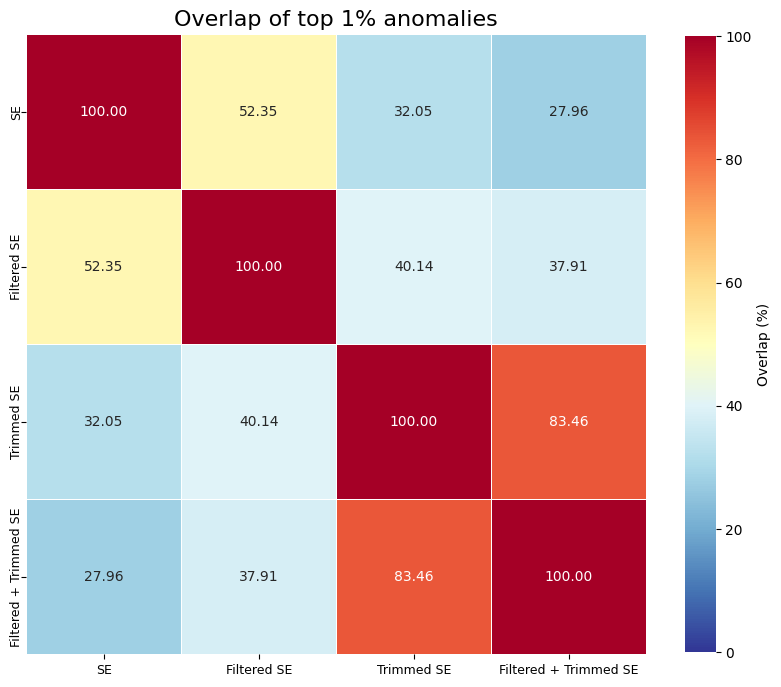

In [47]:
fig = plt.figure(figsize=(10, 10))
mapped_se_cols = [map_score_name(s) for s in se_cols]

sns.heatmap(
    overlap_df.loc[mapped_se_cols, mapped_se_cols], 
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0, vmax=100,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8, "label": "Overlap (%)"}
)
plt.title("Overlap of top 1% anomalies", fontsize=16)
plt.xticks(rotation=0, ha='center', fontsize=9)
plt.yticks(rotation=90, ha='center', fontsize=9)

# save fig
fig.savefig(
    f"{ch_4_dir}/{bin_id}/overlap_ses_{bin_id}.pdf",
    bbox_inches='tight'
)

## RSE family

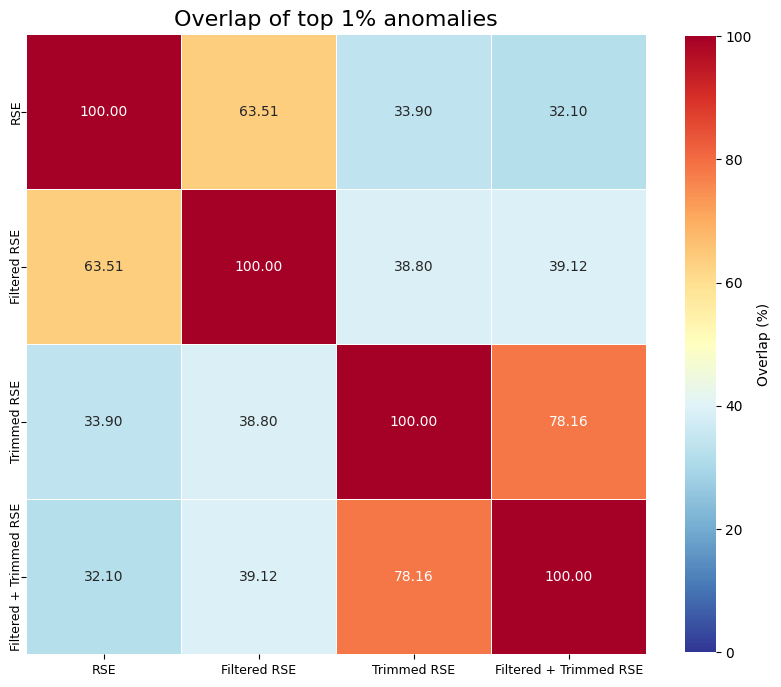

In [48]:
fig = plt.figure(figsize=(10, 10))
mapped_rse_cols = [map_score_name(s) for s in rse_cols]

sns.heatmap(
    overlap_df.loc[mapped_rse_cols, mapped_rse_cols], 
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0, vmax=100,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8, "label": "Overlap (%)"}
)

plt.title("Overlap of top 1% anomalies", fontsize=16)

plt.xticks(rotation=0, ha='center', fontsize=9)
plt.yticks(rotation=90, ha='center', fontsize=9)


fig.savefig(
    f"{ch_4_dir}/{bin_id}/overlap_rses_{bin_id}.pdf",
    bbox_inches='tight'
)

## SE Vs RSE

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, 'SE'),
  Text(0, 1.5, 'Filtered SE'),
  Text(0, 2.5, 'Trimmed SE'),
  Text(0, 3.5, 'Filtered + Trimmed SE')])

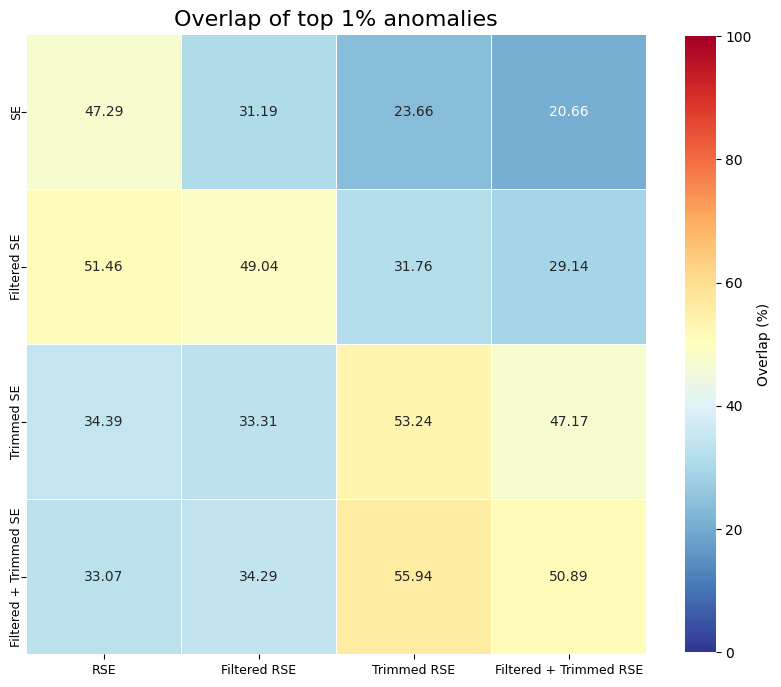

In [49]:
fig = plt.figure(figsize=(10, 10))

mapped_se_cols = [map_score_name(s) for s in se_cols]
mapped_rse_cols = [map_score_name(s) for s in rse_cols]

sns.heatmap(
    overlap_df.loc[mapped_se_cols, mapped_rse_cols], 
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0, vmax=100,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8, "label": "Overlap (%)"}
)

plt.title("Overlap of top 1% anomalies", fontsize=16)
plt.xticks(rotation=0, ha='center', fontsize=9)
plt.yticks(rotation=90, ha='center', fontsize=9)

# fig.savefig(
#     f"{ch_4_dir}/{bin_id}/overlap_all_{bin_id}.pdf",
#     bbox_inches='tight'
# )

# Median specs

# Figs top anomalies

In [ ]:
# # ```python
# n_top = 1000
# all_scores = se_cols + rse_cols
# plt.ioff()

# for score in all_scores:

#     specids_top_1 = score_df[score].sort_values(
#         ascending=False
#     ).index.to_numpy()[:n_top]

#     ranks = np.zeros(n_top).astype(int)

#     specs_top_1 = np.empty((n_top, wave.size))

#     for i, objid in enumerate(specids_top_1):

#         spec_idx = specobjid_to_idx(
#             objid, idx_id_spec
#         )

#         specs_top_1[i, :] = spectra[spec_idx, :]

#         ranks[i] = i

#     # -----------------------------------------------------------

#     save_to = f"{scores_dir}/{bin_id}/figs/{score}"

#     os.makedirs(save_to, exist_ok=True)

#     anomaly_plot(
#         wave_nm, specs=specs_top_1,
#         objids=specids_top_1, ranks=ranks,
#         save_to=save_to
#     )
# # ```